In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

โหลดข้อมูล

In [2]:
df = pd.read_csv('protein.csv')

ตรวจสอบข้อมูลเบื้องต้น

In [7]:
print(f"     สรุปข้อมูลเบื้องต้น ")
print(df.info())

     สรุปข้อมูลเบื้องต้น 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    45730 non-null  float64
 1   F1      45730 non-null  float64
 2   F2      45730 non-null  float64
 3   F3      45730 non-null  float64
 4   F4      45730 non-null  float64
 5   F5      45730 non-null  float64
 6   F6      45730 non-null  float64
 7   F7      45730 non-null  float64
 8   F8      45730 non-null  int64  
 9   F9      45730 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.5 MB
None


ตรวจสอบค่าว่างในdataset

In [10]:
print("จำนวนค่าว่างในแต่ละคอลัมน์")
print(df.isnull().sum())

จำนวนค่าว่างในแต่ละคอลัมน์
RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64


ตรวจสอบข้อมูลซ้ำในdataset

In [11]:
duplicate_rows = df[df.duplicated(keep='first')]
print("ตัวอย่างแถวที่ซ้ำ 5แถวแรก")
print(duplicate_rows.head())

#แสดงข้อมูลที่ซ้ำกันทั้งหมดแสดงให้เห็นเป็นคู่ๆ เพื่อเปรียบเทียบ)
# keep=False จะแสดงทุกแถวที่มีค่าซ้ำกัน
all_duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print("\n--- แสดงข้อมูลที่ซ้ำกันแบบจับคู่เปรียบเทียบ (10 แถวแรก): ---")
print(all_duplicates.head(10))

ตัวอย่างแถวที่ซ้ำ 5แถวแรก
        RMSD        F1       F2       F3        F4            F5        F6  \
1533  16.231   7725.48  2546.72  0.32965   74.6927  1.075574e+06   97.4814   
1890   3.050   9068.27  1995.18  0.22001   96.7449  1.281607e+06  130.6220   
2568   1.864  10202.10  2653.28  0.26007   91.5636  1.453171e+06  137.4020   
2569   2.815  10865.90  3054.63  0.28112  130.6790  1.553053e+06  169.6350   
2809   2.187   8386.68  1860.81  0.22187   83.1233  1.182947e+06  103.6100   

           F7   F8       F9  
1533  3031.49   22  38.5300  
1890  3854.62   48  34.9438  
2568  3649.18  122  35.5868  
2569  4405.85   41  31.7521  
2809  3806.27   19  34.0551  

--- แสดงข้อมูลที่ซ้ำกันแบบจับคู่เปรียบเทียบ (10 แถวแรก): ---
        RMSD       F1       F2       F3       F4            F5       F6  \
29467  0.429  8272.76  2007.39  0.24265  90.2424  1.152668e+06  125.872   
42813  0.429  8272.76  2007.39  0.24265  90.2424  1.152668e+06  125.872   
8011   0.430  8215.46  1965.91  0.2392

ทำการลบแถวที่ข้อมูลซ้ำกัน

In [13]:
#ลบแถวที่มีข้อมูลซ้ำกันทุกคอลัมน์ออก
df_no_duplicates = df.drop_duplicates()

#บันทึกผลลัพธ์ลงในไฟล์ใหม่
df_no_duplicates.to_csv('protein_no_duplicates.csv', index=False)

โหลดข้อมูลใหม่หลังลบคอลัมน์ที่มีข้อมู,ซ้ำออกไป

In [14]:
df = pd.read_csv('protein_no_duplicates.csv')

ตรวจสอบข้อมูลเบื้องต้น

In [15]:
print(f"     สรุปข้อมูลเบื้องต้น ")
print(df.info())

     สรุปข้อมูลเบื้องต้น 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44019 entries, 0 to 44018
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    44019 non-null  float64
 1   F1      44019 non-null  float64
 2   F2      44019 non-null  float64
 3   F3      44019 non-null  float64
 4   F4      44019 non-null  float64
 5   F5      44019 non-null  float64
 6   F6      44019 non-null  float64
 7   F7      44019 non-null  float64
 8   F8      44019 non-null  int64  
 9   F9      44019 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.4 MB
None


พบว่าขคอลัมน์ที่มีข้อมูลซ้ำกันในdataset นี้มีทั้งหมด1,711 แถว จาก45,730 แถว เมื่อลบออกไปจึงเหลือ 44,019 แถว

ทำการตรวจหา Outlierในdataset ด้วยวิธี IQR plotกราฟด้วยวิธีbox plot

 Outlier Summary 
  Column    Lower Bound   Upper Bound  Outlier Count  Percentage (%)
0   RMSD     -14.415750  3.019425e+01              0            0.00
1     F1    -834.912500  1.990007e+04           1113            2.53
2     F2    -735.575000  6.504665e+03           1194            2.71
3     F3       0.131837  4.698175e-01            354            0.80
4     F4     -41.403625  2.386246e+02           1172            2.66
5     F5 -150777.601250  2.795880e+06           1028            2.34
6     F6     -35.210500  3.114479e+02           1249            2.84
7     F7     951.275000  6.860995e+03            525            1.19
8     F8     -59.000000  1.810000e+02           2329            5.29
9     F9      17.771300  5.152850e+01            147            0.33


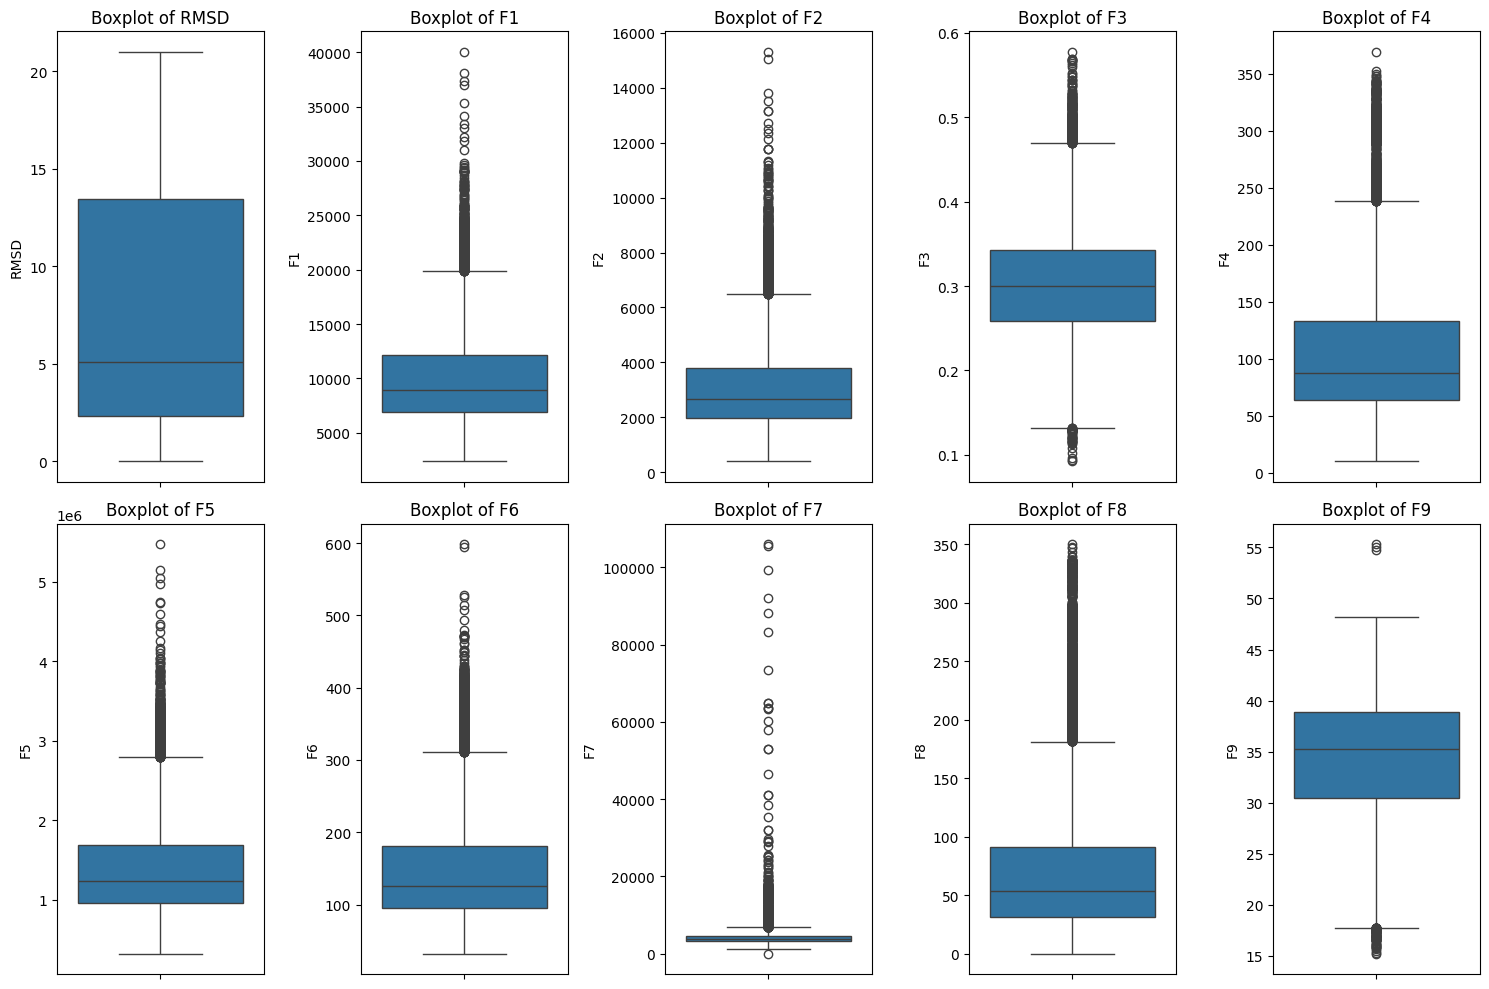

In [17]:
def detect_outliers_iqr(data):
    outlier_indices = []
    outlier_summary = []


    numeric_cols = data.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        #หา Index ของแถวที่เป็น Outlier
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        count = len(outliers)
        percentage = (count / len(data)) * 100

        outlier_summary.append({
            'Column': col,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outlier Count': count,
            'Percentage (%)': round(percentage, 2)
        })

    return pd.DataFrame(outlier_summary)

# แสดงตารางสรุป Outlier
outlier_report = detect_outliers_iqr(df)
print(" Outlier Summary ")
print(outlier_report)

#การสร้าง Boxplot เพื่อดูการกระจายตัวของข้อมูล
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns):
    plt.subplot(2, 5, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

จากที่plotกราฟออกมาดูนั้นพบว่า มีF8 มีปัญหามากที่สุดมี Outlier 5.29% สูงถึง 2,329 แถวซึ่งถือว่าค่อนข้างเยอะเมื่อเทียบกับตัวแปรอื่น

ภาพรวมส่วนใหญ่ ตัวแปรอื่นๆ F1-F6 มี Outlier เฉลี่ยอยู่ที่ 2-3% ซึ่งเป็นลักษณะปกติของข้อมูลทางชีวภาพหรือเคมีที่มีความผันแปรสูง

RMSDเป็นคอลัมน์RMSD ไม่มีOutlier เลย

หลังจากที่ทราบoutlier ในแต่ละคอลัมน์แล้วจึงจัดการoutlier ด้วยวิธีCappin
สาเหตุที่เลือกใช้วิธีการ Cappin นั้น
-รักษาขนาดของข้อมูล
-ลดอิทธิพลของค่าโดด

จัดการoutlier ด้วยวิธีCappin

In [20]:
def cap_outliers_iqr(df, columns):
    df_capped = df.copy()

    for col in columns:
        # คำนวณหาค่า Q1, Q3 และ IQR
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        # กำหนดขอบเขต Lower และ Upper Limit ใช้1.5
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # ทำการ Capping
        # ถ้าค่า > upper_limit ให้แทนด้วย upper_limit
        # ถ้าค่า < lower_limit ให้แทนด้วย lower_limit
        df_capped[col] = np.where(
            df_capped[col] > upper_limit,
            upper_limit,
            np.where(df_capped[col] < lower_limit, lower_limit, df_capped[col])
        )

        print(f"Column {col}: Capped values at [{lower_limit:.2f}, {upper_limit:.2f}]")

    return df_capped

#เลือกคอลัมน์ที่เป็นตัวเลขเพื่อจัดการ Outlier
features_to_cap = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']


df_cleaned = cap_outliers_iqr(df, features_to_cap)

# บันทึกไฟล์ที่จัดการแล้ว
df_cleaned.to_csv('protein_capped.csv', index=False)

# แสดงตัวอย่างสถิติเปรียบเทียบ (คอลัมน์ F1)
print("\n--- Statistics for F1 ---")
print("Original Max:", df['F1'].max())
print("Capped Max  :", df_cleaned['F1'].max())

Column F1: Capped values at [-834.91, 19900.07]
Column F2: Capped values at [-735.58, 6504.66]
Column F3: Capped values at [0.13, 0.47]
Column F4: Capped values at [-41.40, 238.62]
Column F5: Capped values at [-150777.60, 2795879.81]
Column F6: Capped values at [-35.21, 311.45]
Column F7: Capped values at [951.27, 6861.00]
Column F8: Capped values at [-59.00, 181.00]
Column F9: Capped values at [17.77, 51.53]

--- Statistics for F1 ---
Original Max: 40034.9
Capped Max  : 19900.0675


โหลดข้อมูล


In [21]:
df = pd.read_csv('protein_capped.csv')

ตรวจสอบoutlier dataset หลังจากใช้วิธีการCappin plotกราฟด้วยวิธีbox plot

จำนวน Outlier แยกตามคอลัมน์ (วิธี Box Plot / IQR):
RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64


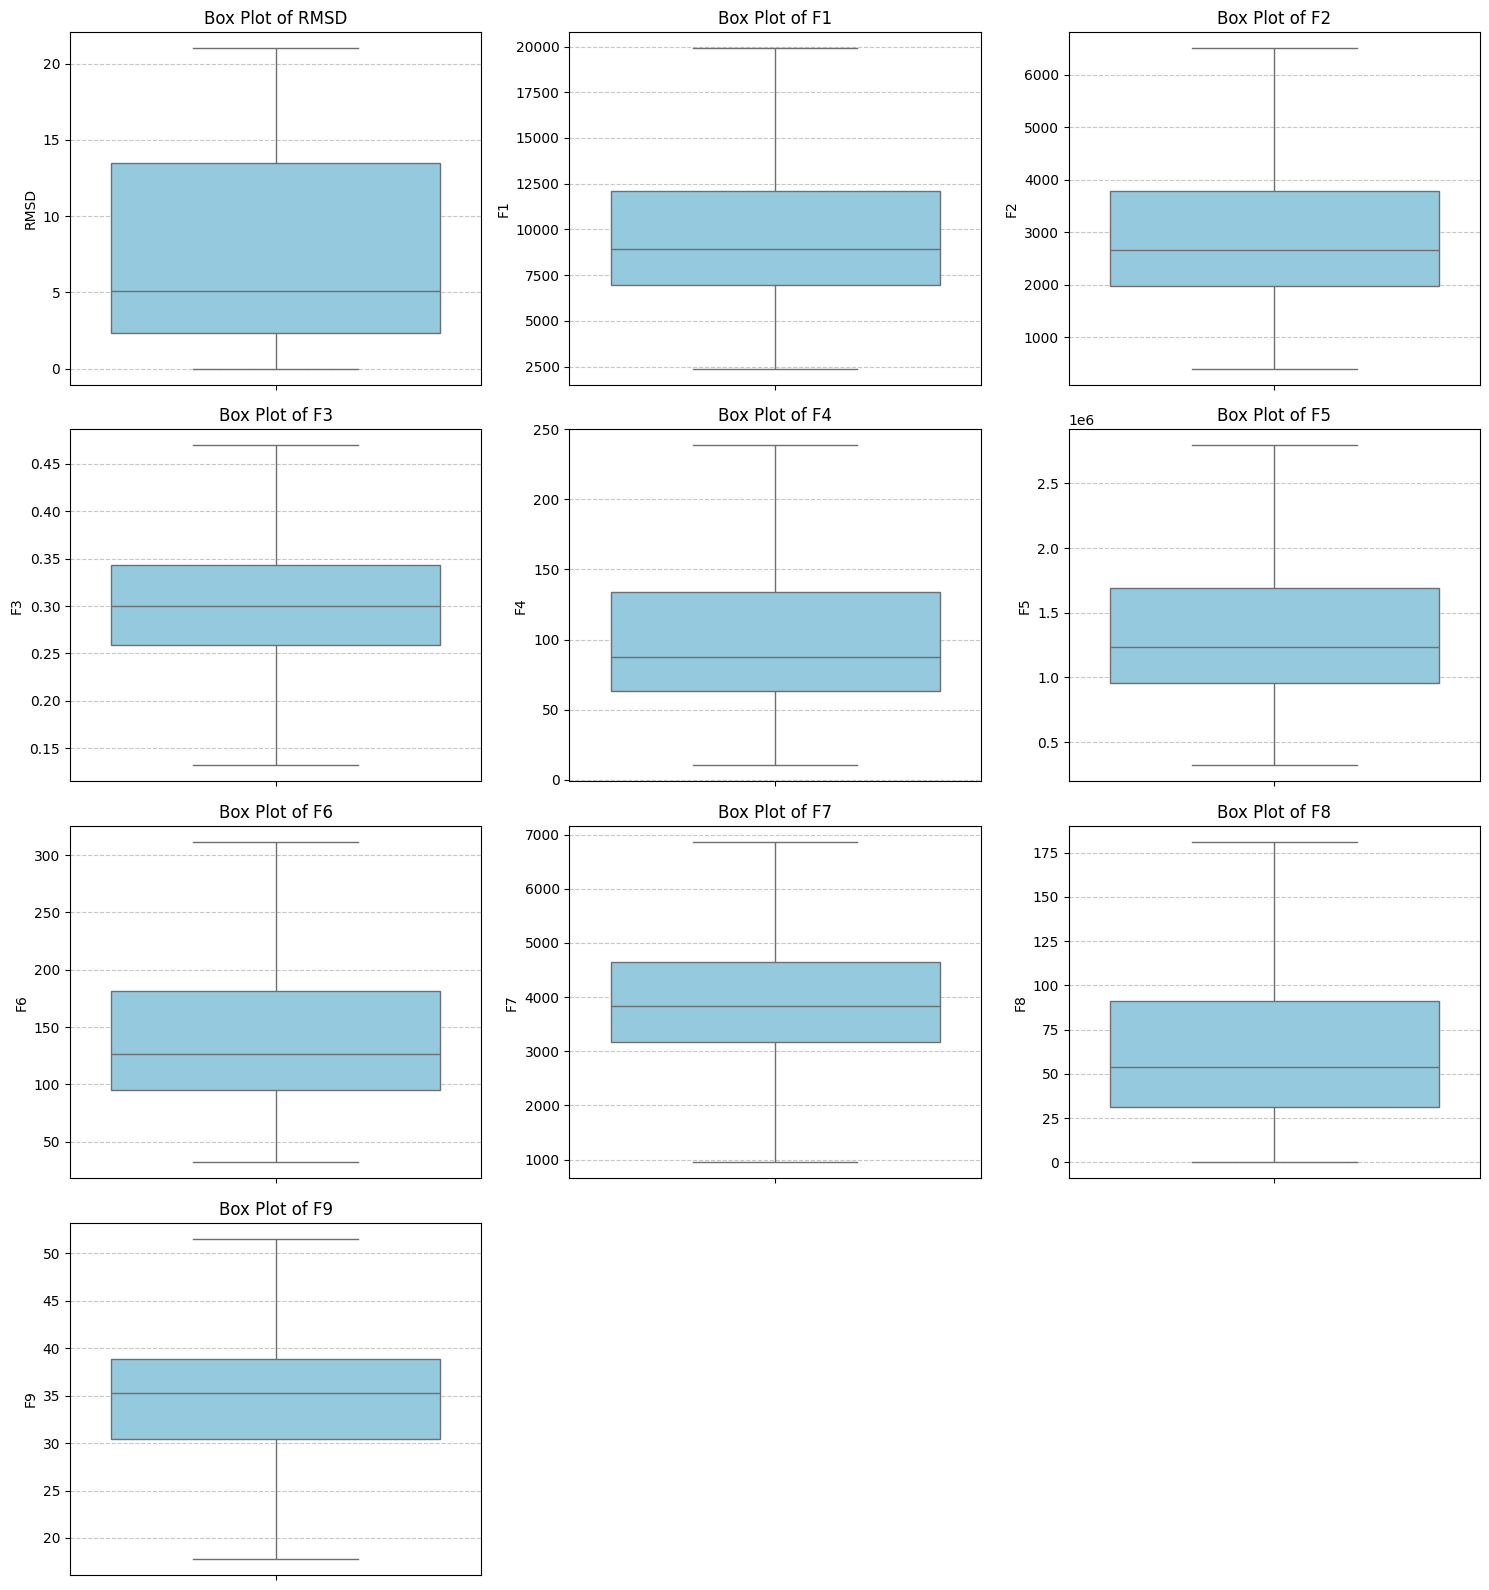

In [22]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# กำหนดช่วงค่าปกติ Lower Upper Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# นับจำนวนค่าที่อยู่นอกช่วงดังกล่าว
outliers_count = ((df < lower_bound) | (df > upper_bound)).sum()

print("จำนวน Outlier แยกตามคอลัมน์ (วิธี Box Plot / IQR):")
print(outliers_count)

# การแสดงผลด้วยกราฟ Box Plot แบบแยกคอลัมน์
# เพื่อป้องกันปัญหาเรื่องมาตราส่วน (Scale) ที่แตกต่างกัน
features = df.columns
n_features = len(features)
cols = 3
rows = (n_features + cols - 1) // cols

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

ไม่พบ Outlier เลยในทุกคอลัมน์ ลักษณะของ Box Plot:จะสังเกตได้ว่า เส้นหนวด Whiskers ของ Box Plot จะครอบคลุมจุดข้อมูลทั้งหมด และไม่มีจุดไข่ปลา Dots ปรากฏอยู่นอกเส้นหนวดเลย ซึ่งเป็นการยืนยันว่าไม่มีค่าใดที่หลุดจากเกณฑ์ 1.5×IQR เลย